# Day 1A — Machine Learning with NumPy and scikit-learn

This notebook is a gentle first contact with machine learning. We generate a fictional
sensor dataset, **look at it first**, and then use standard scikit-learn tools.

The goal is not to optimize every decimal place. It is to understand the path from a
data matrix to a trustworthy prediction.

## 1. What are `X` and `y`?

Each row of `X` is one observation and each column is one measured feature. `y` contains
one target per row: $X \in \mathbb{R}^{n 	imes p}$ and $y \in \mathbb{R}^{n}$.

| Subset | Purpose |
|---|---|
| Training | Learn model parameters |
| Validation | Compare a few model choices |
| Test | One final check at the end |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams["axes.grid"] = True

## 2. Generate the fictional sensor data

The five columns use different units and scales. The target is a fictional concentration
with linear and nonlinear effects plus measurement noise.

In [2]:
n_samples = 600
feature_names = [
    "temperature", "humidity", "sensor_a", "sensor_b", "sensor_age"
]

temperature = rng.uniform(15, 45, n_samples)
humidity = rng.uniform(20, 85, n_samples)
sensor_a = rng.normal(0, 1, n_samples)
sensor_b = 0.65 * sensor_a + rng.normal(0, 0.65, n_samples)
sensor_age = rng.uniform(0, 1, n_samples)

X = np.column_stack([
    temperature, humidity, sensor_a, sensor_b, sensor_age
])
noise = rng.normal(0, 1.8, n_samples)
y = (
    8 + 0.45 * temperature - 0.08 * humidity + 4 * sensor_a
    + 2.5 * sensor_b**2 - 5 * sensor_age + 2 * np.sin(sensor_a) + noise
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600, 5)
y shape: (600,)


### Look at the numbers before fitting a model

The first five rows make the matrix structure concrete. Then plots show the target range,
two feature relationships, and a correlation matrix.

In [3]:
np.set_printoptions(precision=2, suppress=True)
print("Feature order:", feature_names)
print("\nFirst five rows of X:")
print(X[:5])
print("\nFirst five values of y:")
print(y[:5])

Feature order: ['temperature', 'humidity', 'sensor_a', 'sensor_b', 'sensor_age']

First five rows of X:
[[38.22 51.04 -0.99 -1.32  0.49]
 [28.17 69.49 -0.86 -0.65  0.11]
 [40.76 78.72  2.46  0.81  0.24]
 [35.92 66.85  1.8   1.72  0.53]
 [17.83 82.61 -0.41 -0.86  0.07]]

First five values of y:
[18.22 11.99 33.68 30.61  9.85]


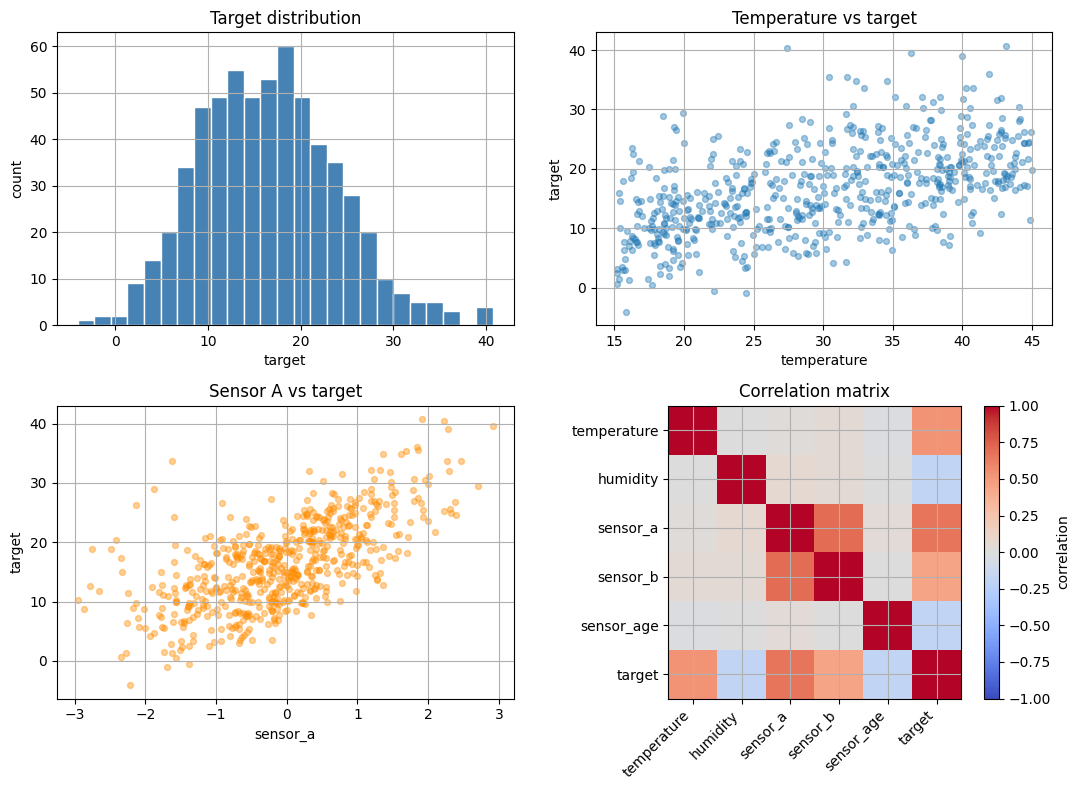

In [4]:
all_names = feature_names + ["target"]
correlation = np.corrcoef(np.column_stack([X, y]), rowvar=False)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(y, bins=25, color="steelblue", edgecolor="white")
axes[0, 0].set(title="Target distribution", xlabel="target", ylabel="count")
axes[0, 1].scatter(temperature, y, alpha=0.4, s=18)
axes[0, 1].set(title="Temperature vs target", xlabel="temperature", ylabel="target")
axes[1, 0].scatter(sensor_a, y, alpha=0.4, s=18, color="darkorange")
axes[1, 0].set(title="Sensor A vs target", xlabel="sensor_a", ylabel="target")

image = axes[1, 1].imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
axes[1, 1].set_title("Correlation matrix")
axes[1, 1].set_xticks(range(6), all_names, rotation=45, ha="right")
axes[1, 1].set_yticks(range(6), all_names)
fig.colorbar(image, ax=axes[1, 1], label="correlation")
fig.tight_layout()

## 3. Split first, preprocess second

We split before calculating scaling values. A scikit-learn pipeline will learn preprocessing
from training rows and reuse it unchanged for new rows.

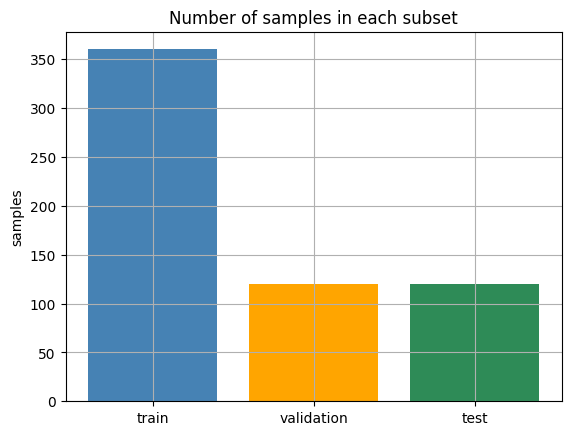

{'train': 360, 'validation': 120, 'test': 120}


In [5]:
X_train, X_other, y_train, y_other = train_test_split(
    X, y, test_size=0.4, random_state=SEED
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_other, y_other, test_size=0.5, random_state=SEED
)

split_names = ["train", "validation", "test"]
split_sizes = [len(X_train), len(X_validation), len(X_test)]
plt.bar(split_names, split_sizes, color=["steelblue", "orange", "seagreen"])
plt.title("Number of samples in each subset")
plt.ylabel("samples")
plt.show()
print(dict(zip(split_names, split_sizes)))

### What does scaling do to the matrix?

`StandardScaler` centers and scales each training column. The heatmaps show the same first
20 rows before and after scaling.

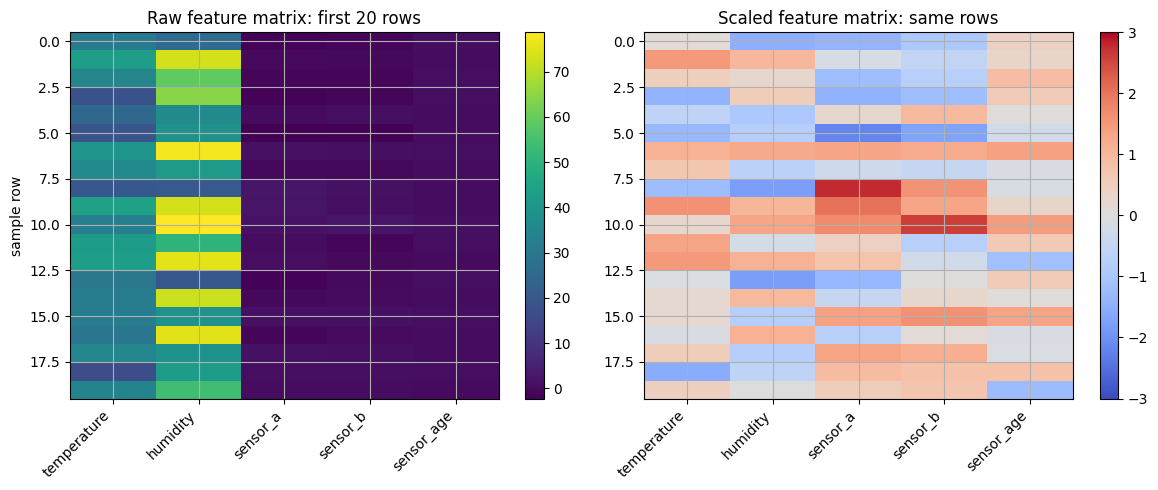

In [6]:
display_scaler = StandardScaler()
X_train_scaled = display_scaler.fit_transform(X_train)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

raw = axes[0].imshow(X_train[:20], aspect="auto", cmap="viridis")
axes[0].set_title("Raw feature matrix: first 20 rows")
axes[0].set_xticks(range(5), feature_names, rotation=45, ha="right")
axes[0].set_ylabel("sample row")
fig.colorbar(raw, ax=axes[0])

scaled = axes[1].imshow(
    X_train_scaled[:20], aspect="auto", cmap="coolwarm", vmin=-3, vmax=3
)
axes[1].set_title("Scaled feature matrix: same rows")
axes[1].set_xticks(range(5), feature_names, rotation=45, ha="right")
fig.colorbar(scaled, ax=axes[1])
fig.tight_layout()

## 4. First regression model

The pipeline scales the columns and fits `LinearRegression`. The mean of the training targets
is our simple baseline. All algorithm work comes from tested scikit-learn estimators.

In [7]:
mean_prediction = np.full_like(y_validation, y_train.mean())
linear_model = make_pipeline(StandardScaler(), LinearRegression())
linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_validation)

baseline_rmse = mean_squared_error(y_validation, mean_prediction) ** 0.5
linear_rmse = mean_squared_error(y_validation, linear_prediction) ** 0.5
print(f"Mean baseline RMSE: {baseline_rmse:.2f}")
print(f"Linear model RMSE:  {linear_rmse:.2f}")
print(f"Linear model MAE:   {mean_absolute_error(y_validation, linear_prediction):.2f}")
print(f"Linear model R²:    {r2_score(y_validation, linear_prediction):.2f}")

Mean baseline RMSE: 7.22
Linear model RMSE:  2.93
Linear model MAE:   2.26
Linear model R²:    0.84


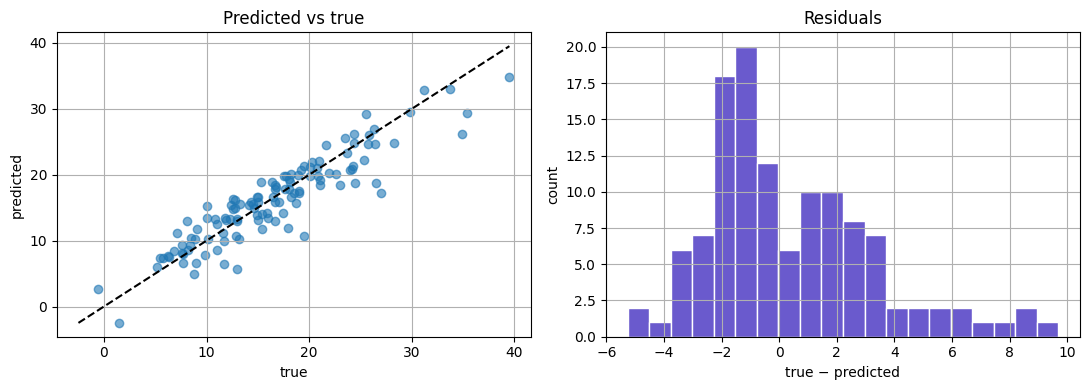

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_validation, linear_prediction, alpha=0.6)
limits = [
    min(y_validation.min(), linear_prediction.min()),
    max(y_validation.max(), linear_prediction.max()),
]
axes[0].plot(limits, limits, "k--")
axes[0].set(title="Predicted vs true", xlabel="true", ylabel="predicted")
residuals = y_validation - linear_prediction
axes[1].hist(residuals, bins=20, color="slateblue", edgecolor="white")
axes[1].set(title="Residuals", xlabel="true − predicted", ylabel="count")
fig.tight_layout()

## 5. One gentle hyperparameter example

`alpha` controls how strongly Ridge shrinks coefficients. We vary **only this one setting**
and try only three values. Large searches belong in a later course section.

In [9]:
ridge_results = []
for alpha in [0.1, 1.0, 10.0]:
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(X_train, y_train)
    prediction = model.predict(X_validation)
    rmse = mean_squared_error(y_validation, prediction) ** 0.5
    ridge_results.append((alpha, rmse, model))
    print(f"alpha={alpha:>4}: validation RMSE={rmse:.2f}")

best_alpha, ridge_rmse, ridge_model = min(
    ridge_results, key=lambda result: result[1]
)
print("Selected alpha:", best_alpha)

alpha= 0.1: validation RMSE=2.93
alpha= 1.0: validation RMSE=2.93
alpha=10.0: validation RMSE=2.92
Selected alpha: 10.0


## 6. Missing values: use one readable pipeline

Real tables can contain missing values. This pipeline says exactly what happens: fill missing
values, scale features, then fit Ridge regression.

In [10]:
X_missing = X_train.copy()
X_missing[rng.random(X_missing.shape) < 0.02] = np.nan

safe_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    Ridge(alpha=best_alpha),
)
safe_pipeline.fit(X_missing, y_train)
print("Missing cells:", np.isnan(X_missing).sum())
print("Pipeline steps:", list(safe_pipeline.named_steps))

Missing cells: 32
Pipeline steps: ['simpleimputer', 'standardscaler', 'ridge']


## 7. Compare one nonlinear model

A random forest can represent nonlinear patterns. We keep its settings fixed and compare it
with the two linear models on the same validation data.

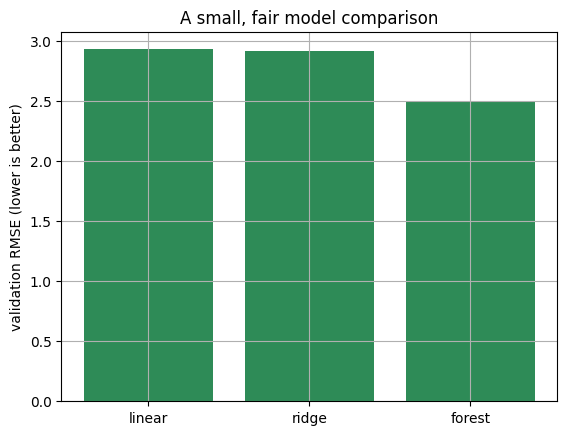

{'linear': 2.9299492716063043, 'ridge': 2.9173409399442853, 'forest': 2.4938452307813597}


In [11]:
forest_model = RandomForestRegressor(
    n_estimators=150, max_depth=8, random_state=SEED
)
forest_model.fit(X_train, y_train)
forest_prediction = forest_model.predict(X_validation)
forest_rmse = mean_squared_error(y_validation, forest_prediction) ** 0.5
scores = {"linear": linear_rmse, "ridge": ridge_rmse, "forest": forest_rmse}

plt.bar(scores.keys(), scores.values(), color="seagreen")
plt.ylabel("validation RMSE (lower is better)")
plt.title("A small, fair model comparison")
plt.show()
print(scores)

## 8. Classification with scikit-learn

“High concentration” means above the training median. Logistic regression predicts the class;
a confusion matrix makes correct and incorrect decisions visible.

Validation accuracy: 90.00%


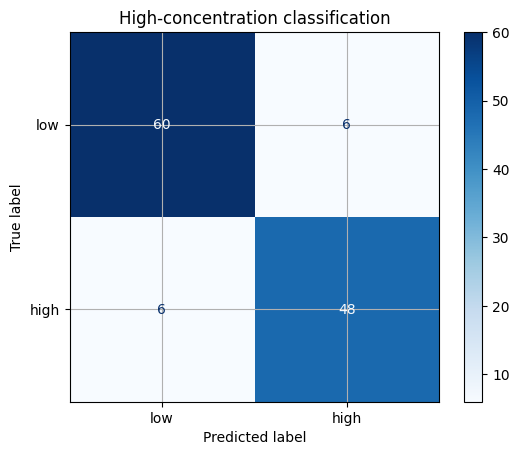

In [12]:
threshold = np.median(y_train)
class_train = (y_train > threshold).astype(int)
class_validation = (y_validation > threshold).astype(int)
classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1_000))
classifier.fit(X_train, class_train)
class_prediction = classifier.predict(X_validation)

accuracy = accuracy_score(class_validation, class_prediction)
print(f"Validation accuracy: {accuracy:.2%}")
ConfusionMatrixDisplay.from_predictions(
    class_validation, class_prediction, display_labels=["low", "high"], cmap="Blues"
)
plt.title("High-concentration classification")
plt.show()

## 9. Open the test set once

Choose by validation RMSE, refit on training plus validation rows, and evaluate the untouched
test set once.

In [13]:
candidates = {"linear": linear_model, "ridge": ridge_model, "forest": forest_model}
selected_name = min(scores, key=scores.get)
final_model = clone(candidates[selected_name])
X_development = np.vstack([X_train, X_validation])
y_development = np.concatenate([y_train, y_validation])
final_model.fit(X_development, y_development)
test_prediction = final_model.predict(X_test)

print("Selected model:", selected_name)
print(f"Test MAE:  {mean_absolute_error(y_test, test_prediction):.2f}")
print(f"Test RMSE: {mean_squared_error(y_test, test_prediction) ** 0.5:.2f}")
print(f"Test R²:   {r2_score(y_test, test_prediction):.2f}")

Selected model: forest
Test MAE:  2.23
Test RMSE: 2.90
Test R²:   0.85


## Takeaways

- Look at values, plots, and matrix shapes before modeling.
- Split before learning preprocessing values.
- Use scikit-learn's standard `fit` / `predict` workflow.
- For a first hyperparameter example, vary one setting over a few values.
- Keep the test set closed until the model choice is fixed.